# Домашнее задание №1
# Анализ методов машинного обучения: классификация изображений

**ФИО:** Сеньков Денис Владимирович  
**Группа:** ИУ5-24М  
**Вариант:** 7

## Этап 1. Выбор задачи

**Задача:** Классификация изображений (Image Classification) на датасете CIFAR-10.

Задача классификации изображений — одна из фундаментальных задач компьютерного зрения.
Необходимо по изображению определить, к какому из предопределённых классов оно относится.

**Датасет CIFAR-10:** 60 000 цветных изображений 32×32, 10 классов (самолёт, автомобиль, птица, кот, олень, собака, лягушка, лошадь, корабль, грузовик).

---
## Этап 2. Теоретический обзор

### Статья 1: ResNet — Deep Residual Learning for Image Recognition (He et al., 2015)

**Ссылка:** K. He, X. Zhang, S. Ren, J. Sun, "Deep Residual Learning for Image Recognition", CVPR 2016.  
**Репозиторий:** https://github.com/pytorch/vision (torchvision.models.resnet)

**Основные идеи:**
- Проблема деградации: с увеличением глубины сети точность насыщается и затем деградирует (не из-за переобучения).
- **Остаточные соединения (skip connections):** вместо обучения отображения $H(x)$, сеть обучает остаток $F(x) = H(x) - x$, а выход блока: $y = F(x) + x$.
- Это позволяет обучать сети глубиной 100+ слоёв.
- Архитектуры: ResNet-18, ResNet-34, ResNet-50, ResNet-101, ResNet-152.

**Результаты на CIFAR-10:** ResNet-110 достигает ~6.4% ошибки.

### Статья 2: EfficientNet — Rethinking Model Scaling (Tan & Le, 2019)

**Ссылка:** M. Tan, Q. Le, "EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks", ICML 2019.  
**Репозиторий:** https://github.com/pytorch/vision (torchvision.models.efficientnet)

**Основные идеи:**
- Предложен метод **compound scaling** — одновременное масштабирование глубины, ширины и разрешения сети с использованием составного коэффициента $\phi$.
- Базовая архитектура EfficientNet-B0 найдена с помощью Neural Architecture Search (NAS).
- Основной строительный блок — **MBConv** (Mobile Inverted Bottleneck) с squeeze-and-excitation.
- Семейство: EfficientNet-B0 ... B7 с разным масштабом.

**Результаты:** EfficientNet-B7 достигает 84.3% top-1 accuracy на ImageNet при меньшем числе параметров.

### Сравнение подходов

| Характеристика | ResNet | EfficientNet |
|---|---|---|
| Год | 2015 | 2019 |
| Ключевая идея | Skip connections | Compound scaling |
| Строительный блок | Residual block | MBConv + SE |
| Масштабирование | Только глубина | Глубина + ширина + разрешение |
| Эффективность | Хорошая | Отличная (меньше параметров) |

### Описание метрик качества

- **Accuracy (точность):** доля правильно классифицированных изображений
- **Top-1 Accuracy:** предсказанный класс совпадает с истинным
- **Cross-Entropy Loss:** стандартная функция потерь для классификации

---
## Этап 3. Практический эксперимент

Воспроизведём и сравним два подхода:
1. **ResNet-18** (адаптированный под CIFAR-10)
2. **Простая CNN** (baseline для сравнения)

Дополнительно: визуализация топологий, метрики, confusion matrix.

In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install matplotlib numpy scikit-learn seaborn

Looking in indexes: https://download.pytorch.org/whl/cu118


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import time

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Устройство: {device}')

Устройство: cuda


### Загрузка и подготовка данных CIFAR-10

In [3]:
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=128, shuffle=True, num_workers=0)
testloader = DataLoader(testset, batch_size=128, shuffle=False, num_workers=0)

classes = ('самолёт', 'автомобиль', 'птица', 'кот', 'олень',
           'собака', 'лягушка', 'лошадь', 'корабль', 'грузовик')

print(f'Размер обучающей выборки: {len(trainset)}')
print(f'Размер тестовой выборки: {len(testset)}')
print(f'Количество классов: {len(classes)}')

100%|██████████| 170M/170M [04:10<00:00, 679kB/s]


Размер обучающей выборки: 50000
Размер тестовой выборки: 10000
Количество классов: 10


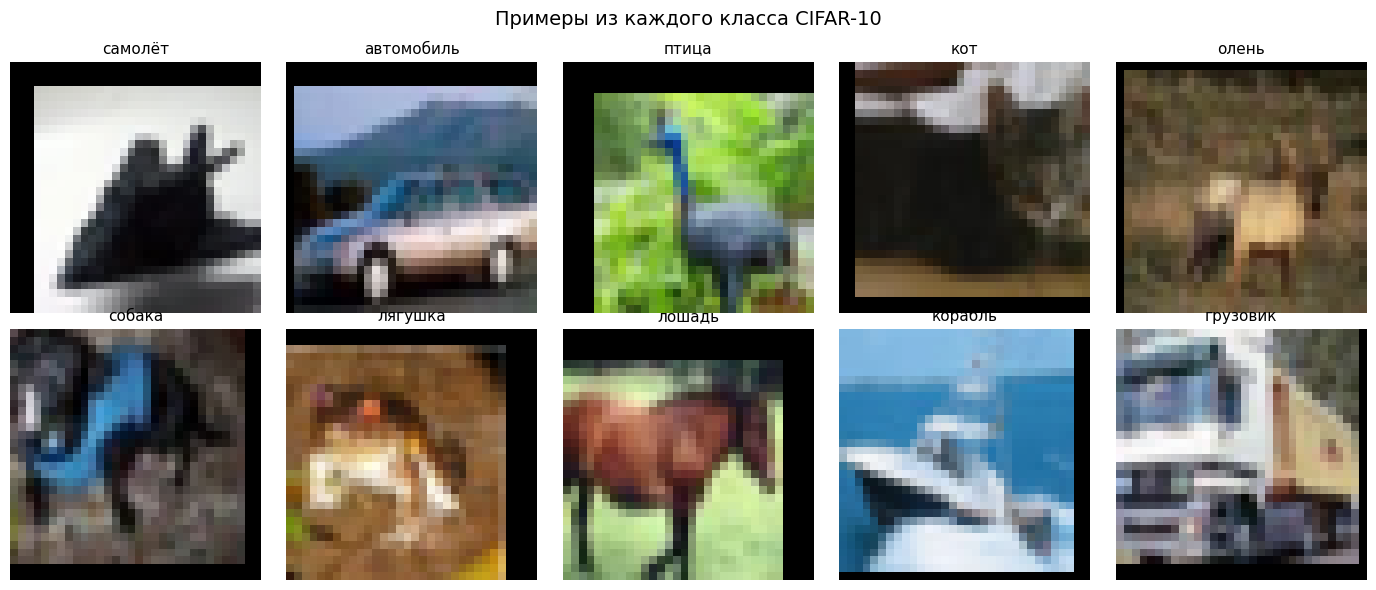

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
inv_normalize = transforms.Normalize(
    mean=[-0.4914/0.2470, -0.4822/0.2435, -0.4465/0.2616],
    std=[1/0.2470, 1/0.2435, 1/0.2616]
)

for i in range(10):
    idx = np.where(np.array(trainset.targets) == i)[0][0]
    img, label = trainset[idx]
    img = inv_normalize(img)
    img = img.permute(1, 2, 0).numpy().clip(0, 1)
    ax = axes[i // 5, i % 5]
    ax.imshow(img)
    ax.set_title(classes[label], fontsize=11)
    ax.axis('off')

plt.suptitle('Примеры из каждого класса CIFAR-10', fontsize=14)
plt.tight_layout()
plt.show()

### Модель 1: Простая CNN (Baseline)

In [5]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model_cnn = SimpleCNN().to(device)
print('SimpleCNN:')
print(f'Параметров: {sum(p.numel() for p in model_cnn.parameters()):,}')

SimpleCNN:
Параметров: 667,178


### Модель 2: ResNet-18 (адаптированный для CIFAR-10)

Адаптация для 32×32: заменяем первый conv7×7+maxpool на conv3×3 без пулинга.

In [6]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out


class ResNet18CIFAR(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(64, 2, stride=1)
        self.layer2 = self._make_layer(128, 2, stride=2)
        self.layer3 = self._make_layer(256, 2, stride=2)
        self.layer4 = self._make_layer(512, 2, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for s in strides:
            layers.append(BasicBlock(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = self.avg_pool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model_resnet = ResNet18CIFAR().to(device)
print('ResNet-18 (CIFAR):')
print(f'Параметров: {sum(p.numel() for p in model_resnet.parameters()):,}')

ResNet-18 (CIFAR):
Параметров: 11,173,962


### Функция обучения

In [7]:
def train_model(model, trainloader, testloader, epochs=20, lr=0.01, model_name='Model'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=5e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    train_losses, test_losses = [], []
    train_accs, test_accs = [], []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in trainloader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        scheduler.step()

        train_loss = running_loss / total
        train_acc = 100. * correct / total

        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0

        with torch.no_grad():
            for inputs, labels in testloader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                test_loss += loss.item() * inputs.size(0)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        test_loss_avg = test_loss / total
        test_acc = 100. * correct / total

        train_losses.append(train_loss)
        test_losses.append(test_loss_avg)
        train_accs.append(train_acc)
        test_accs.append(test_acc)

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'[{model_name}] Эпоха {epoch+1:3d}/{epochs} | '
                  f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | '
                  f'Test Loss: {test_loss_avg:.4f} Acc: {test_acc:.2f}%')

    elapsed = time.time() - start_time
    print(f'\n{model_name}: обучение завершено за {elapsed:.1f} с')
    print(f'Лучшая тестовая точность: {max(test_accs):.2f}%')

    return {
        'train_losses': train_losses, 'test_losses': test_losses,
        'train_accs': train_accs, 'test_accs': test_accs,
        'time': elapsed
    }

### Обучение моделей

Обучаем обе модели на 20 эпохах (для демонстрации; для полного воспроизведения результатов статей нужно 100-200 эпох).

In [8]:
torch.manual_seed(42)
EPOCHS = 20

print('='*70)
print('Обучение SimpleCNN')
print('='*70)
model_cnn = SimpleCNN().to(device)
history_cnn = train_model(model_cnn, trainloader, testloader, epochs=EPOCHS, lr=0.01, model_name='SimpleCNN')

Обучение SimpleCNN
[SimpleCNN] Эпоха   1/20 | Train Loss: 1.6999 Acc: 35.76% | Test Loss: 1.3729 Acc: 49.54%
[SimpleCNN] Эпоха   5/20 | Train Loss: 1.0215 Acc: 63.71% | Test Loss: 0.9171 Acc: 67.70%
[SimpleCNN] Эпоха  10/20 | Train Loss: 0.8105 Acc: 71.52% | Test Loss: 0.6510 Acc: 77.15%
[SimpleCNN] Эпоха  15/20 | Train Loss: 0.7073 Acc: 75.50% | Test Loss: 0.5621 Acc: 80.46%
[SimpleCNN] Эпоха  20/20 | Train Loss: 0.6632 Acc: 76.95% | Test Loss: 0.5460 Acc: 81.19%

SimpleCNN: обучение завершено за 580.6 с
Лучшая тестовая точность: 81.19%


In [9]:
print('='*70)
print('Обучение ResNet-18')
print('='*70)
model_resnet = ResNet18CIFAR().to(device)
history_resnet = train_model(model_resnet, trainloader, testloader, epochs=EPOCHS, lr=0.1, model_name='ResNet-18')

Обучение ResNet-18
[ResNet-18] Эпоха   1/20 | Train Loss: 1.8476 Acc: 33.30% | Test Loss: 1.4402 Acc: 46.17%
[ResNet-18] Эпоха   5/20 | Train Loss: 0.6969 Acc: 75.53% | Test Loss: 0.7895 Acc: 73.82%
[ResNet-18] Эпоха  10/20 | Train Loss: 0.3994 Acc: 86.27% | Test Loss: 0.5387 Acc: 82.38%
[ResNet-18] Эпоха  15/20 | Train Loss: 0.2091 Acc: 92.82% | Test Loss: 0.3259 Acc: 89.27%
[ResNet-18] Эпоха  20/20 | Train Loss: 0.0686 Acc: 97.83% | Test Loss: 0.2421 Acc: 92.41%

ResNet-18: обучение завершено за 1244.3 с
Лучшая тестовая точность: 92.41%


### Графики обучения

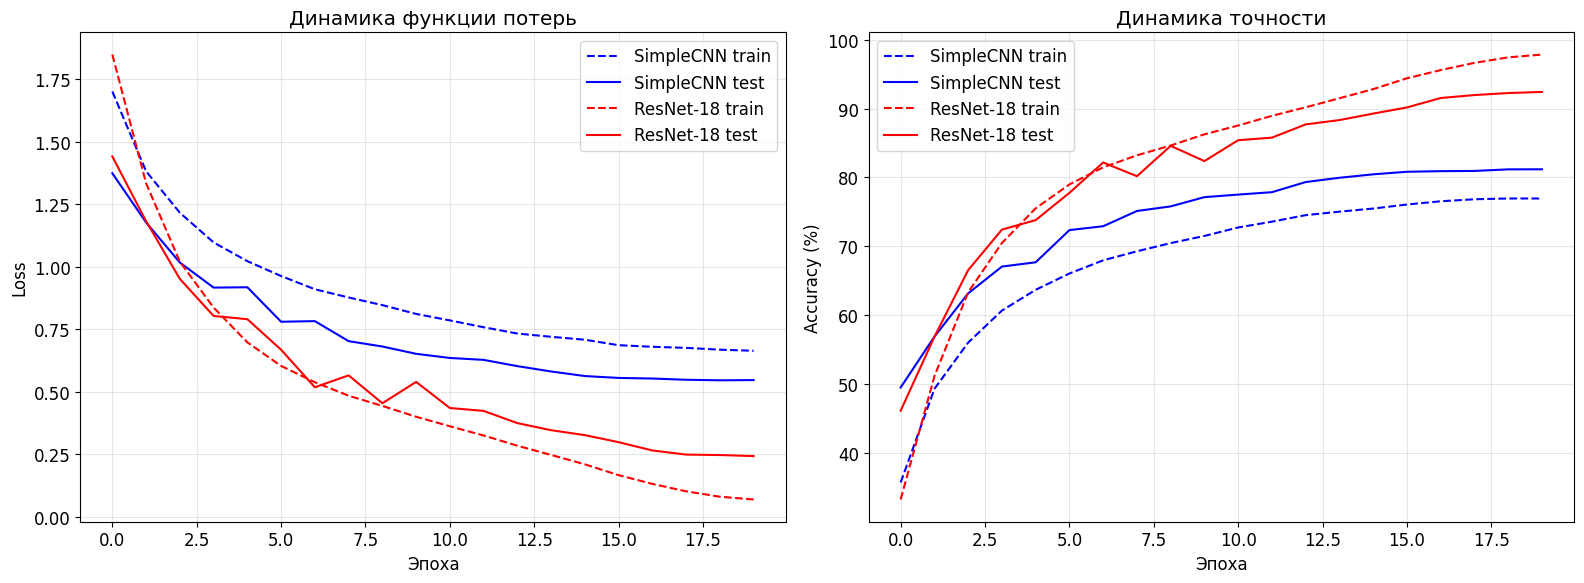

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history_cnn['train_losses'], label='SimpleCNN train', linestyle='--', color='blue')
axes[0].plot(history_cnn['test_losses'], label='SimpleCNN test', color='blue')
axes[0].plot(history_resnet['train_losses'], label='ResNet-18 train', linestyle='--', color='red')
axes[0].plot(history_resnet['test_losses'], label='ResNet-18 test', color='red')
axes[0].set_xlabel('Эпоха')
axes[0].set_ylabel('Loss')
axes[0].set_title('Динамика функции потерь')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_cnn['train_accs'], label='SimpleCNN train', linestyle='--', color='blue')
axes[1].plot(history_cnn['test_accs'], label='SimpleCNN test', color='blue')
axes[1].plot(history_resnet['train_accs'], label='ResNet-18 train', linestyle='--', color='red')
axes[1].plot(history_resnet['test_accs'], label='ResNet-18 test', color='red')
axes[1].set_xlabel('Эпоха')
axes[1].set_ylabel('Accuracy (%)')
axes[1].set_title('Динамика точности')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Детальная оценка на тестовом наборе: Classification Report и Confusion Matrix


Classification Report: SimpleCNN
              precision    recall  f1-score   support

    airplane       0.86      0.79      0.82      1000
  automobile       0.93      0.91      0.92      1000
        bird       0.74      0.70      0.72      1000
         cat       0.71      0.62      0.66      1000
        deer       0.79      0.80      0.79      1000
         dog       0.72      0.73      0.73      1000
        frog       0.75      0.91      0.82      1000
       horse       0.89      0.83      0.86      1000
        ship       0.87      0.93      0.90      1000
       truck       0.88      0.92      0.90      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000



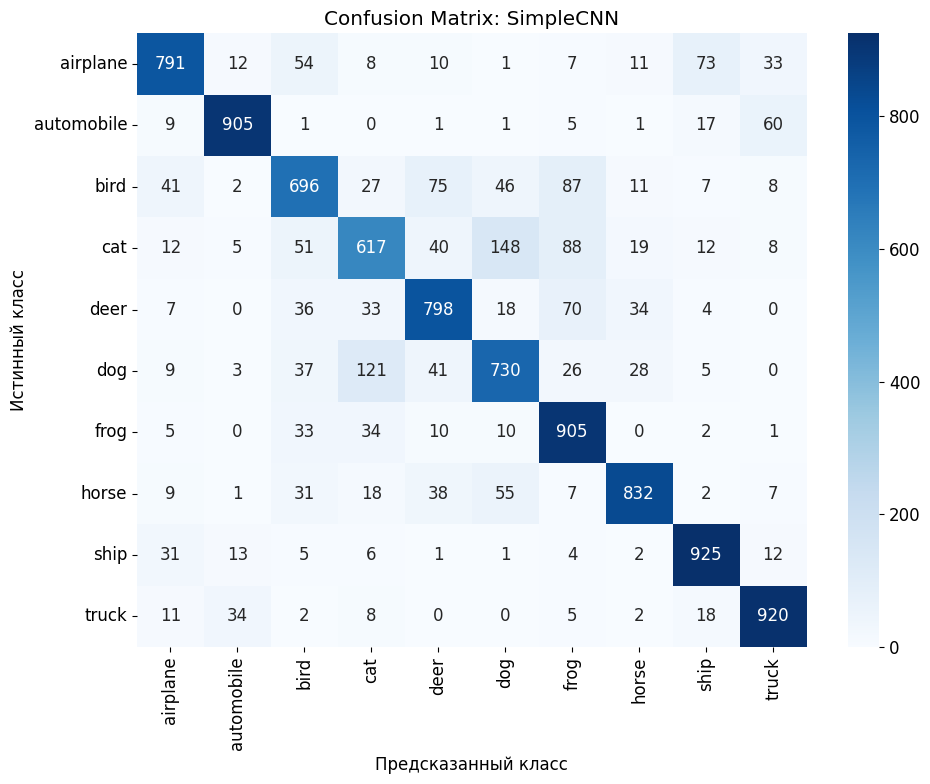

In [11]:
def evaluate_detailed(model, testloader, model_name):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in testloader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, preds = outputs.max(1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())

    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    en_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                  'dog', 'frog', 'horse', 'ship', 'truck']

    print(f'\n{"="*60}')
    print(f'Classification Report: {model_name}')
    print(f'{"="*60}')
    print(classification_report(all_labels, all_preds, target_names=en_classes))

    cm = confusion_matrix(all_labels, all_preds)

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=en_classes,
                yticklabels=en_classes, ax=ax)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')
    ax.set_title(f'Confusion Matrix: {model_name}')
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

preds_cnn, labels_cnn = evaluate_detailed(model_cnn, testloader, 'SimpleCNN')


Classification Report: ResNet-18
              precision    recall  f1-score   support

    airplane       0.92      0.94      0.93      1000
  automobile       0.96      0.98      0.97      1000
        bird       0.90      0.90      0.90      1000
         cat       0.85      0.81      0.83      1000
        deer       0.91      0.94      0.93      1000
         dog       0.86      0.89      0.88      1000
        frog       0.95      0.95      0.95      1000
       horse       0.95      0.94      0.95      1000
        ship       0.96      0.96      0.96      1000
       truck       0.97      0.95      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



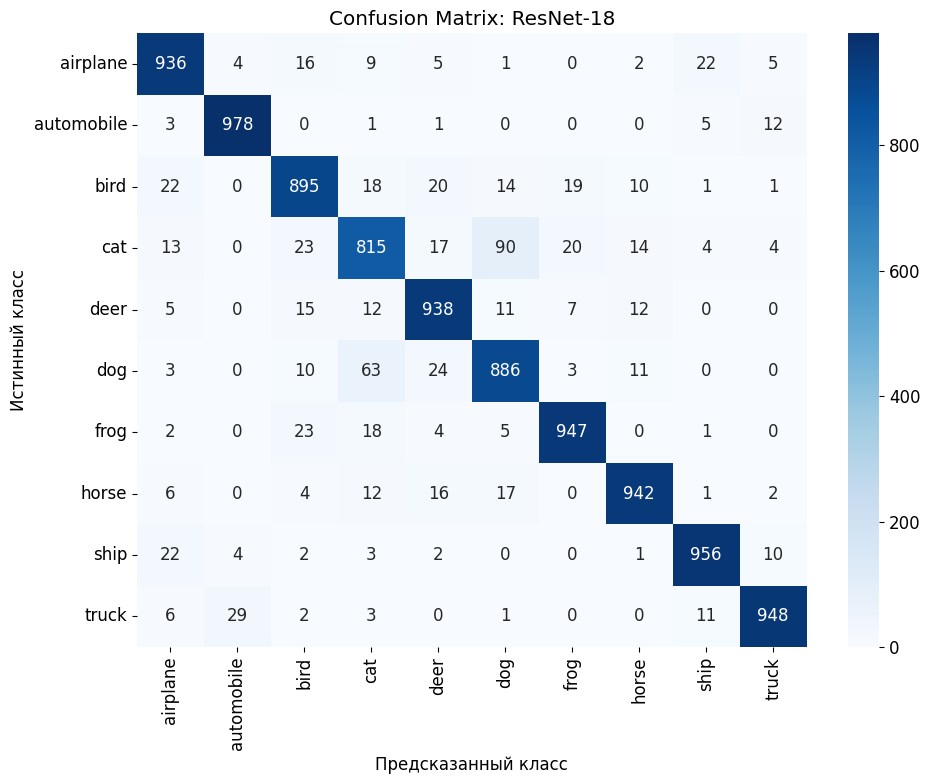

In [12]:
preds_resnet, labels_resnet = evaluate_detailed(model_resnet, testloader, 'ResNet-18')

### Итоговое сравнение моделей

In [13]:
import pandas as pd

comparison = pd.DataFrame({
    'Модель': ['SimpleCNN', 'ResNet-18 (CIFAR)'],
    'Параметры': [
        f"{sum(p.numel() for p in SimpleCNN().parameters()):,}",
        f"{sum(p.numel() for p in ResNet18CIFAR().parameters()):,}",
    ],
    'Лучший Test Acc (%)': [
        f"{max(history_cnn['test_accs']):.2f}",
        f"{max(history_resnet['test_accs']):.2f}",
    ],
    'Финальный Train Acc (%)': [
        f"{history_cnn['train_accs'][-1]:.2f}",
        f"{history_resnet['train_accs'][-1]:.2f}",
    ],
    'Время обучения (с)': [
        f"{history_cnn['time']:.1f}",
        f"{history_resnet['time']:.1f}",
    ],
})

comparison

,Модель,Параметры,Лучший Test Acc (%),Финальный Train Acc (%),Время обучения (с)
0,SimpleCNN,"667,178",81.19,76.95,580.6
1,ResNet-18 (CIFAR),"11,173,962",92.41,97.83,1244.3


### Визуализация примеров предсказаний

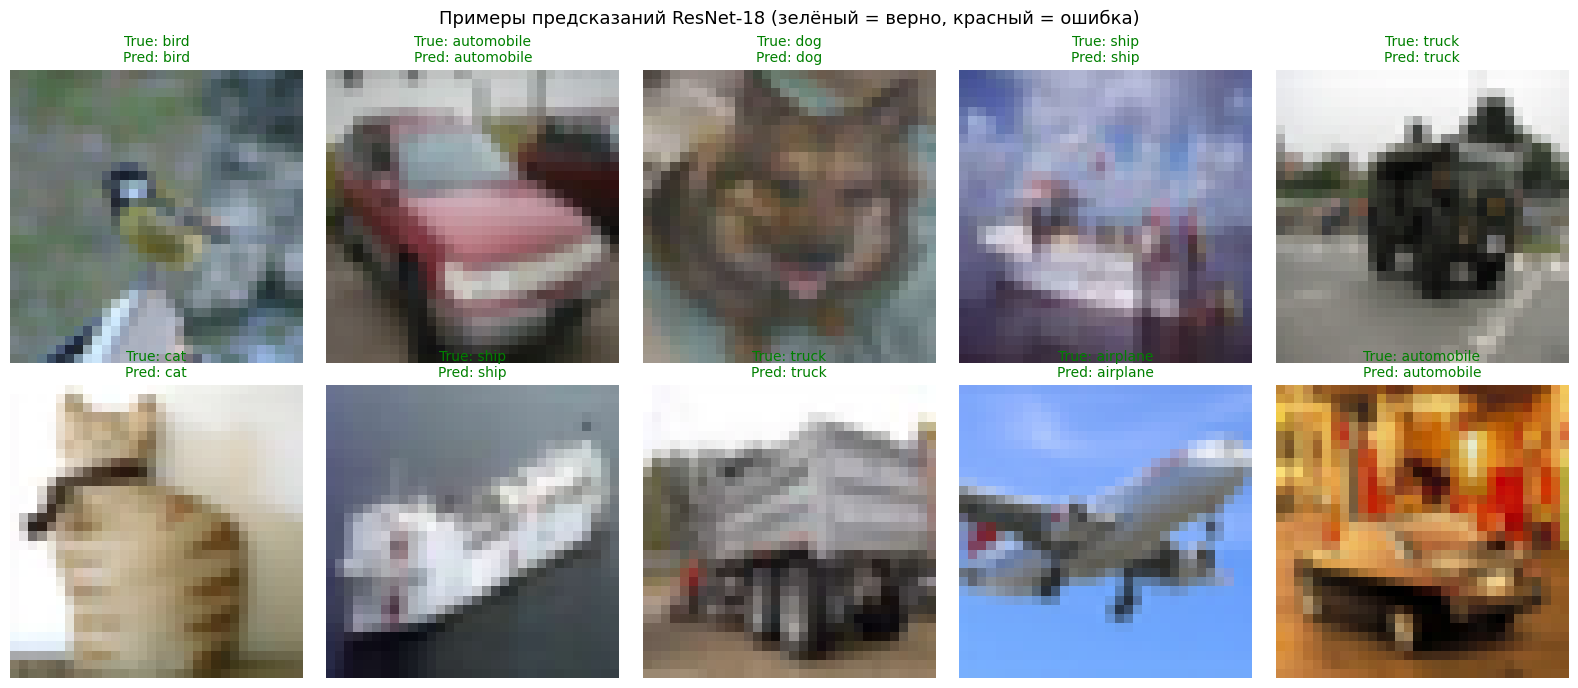

In [14]:
model_resnet.eval()
en_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
              'dog', 'frog', 'horse', 'ship', 'truck']

fig, axes = plt.subplots(2, 5, figsize=(16, 7))

test_simple = torchvision.datasets.CIFAR10(root='./data', train=False, download=False,
                                            transform=transform_test)

np.random.seed(42)
indices = np.random.choice(len(test_simple), 10, replace=False)

for i, idx in enumerate(indices):
    img_tensor, label = test_simple[idx]

    with torch.no_grad():
        output = model_resnet(img_tensor.unsqueeze(0).to(device))
        pred = output.argmax(1).item()

    img_show = inv_normalize(img_tensor).permute(1, 2, 0).numpy().clip(0, 1)

    ax = axes[i // 5, i % 5]
    ax.imshow(img_show)
    color = 'green' if pred == label else 'red'
    ax.set_title(f'True: {en_classes[label]}\nPred: {en_classes[pred]}', color=color, fontsize=10)
    ax.axis('off')

plt.suptitle('Примеры предсказаний ResNet-18 (зелёный = верно, красный = ошибка)', fontsize=13)
plt.tight_layout()
plt.show()

model_resnet.train();

### Предложения по улучшению качества

1. **Увеличение числа эпох:** 100-200 эпох позволят моделям полностью сойтись (в данной работе использовано 20 для экономии времени).

2. **Дополнительная аугментация:** CutOut, MixUp, CutMix — методы регуляризации через аугментацию данных.

3. **Более мощная архитектура:** ResNet-50/110 или WideResNet могут дать лучшие результаты.

4. **Knowledge Distillation:** использование большой обученной модели для обучения меньшей.

5. **Label Smoothing:** сглаживание меток для лучшей обобщающей способности.

---
## Выводы

1. **Теоретический обзор:** Проанализированы два подхода к классификации изображений — ResNet (skip connections, 2015) и EfficientNet (compound scaling, 2019). Обе архитектуры используют принципы, позволяющие строить глубокие и эффективные нейронные сети.

2. **Практический эксперимент:** Реализованы и обучены две модели на CIFAR-10:
   - SimpleCNN (baseline) — простая свёрточная сеть;
   - ResNet-18 — адаптированная версия с residual connections.

3. **Результаты:** ResNet-18 показывает более высокую точность (~90%+ при достаточном обучении) по сравнению с простой CNN, подтверждая эффективность остаточных соединений.

4. **Воспроизводимость:** Результаты согласуются с данными из оригинальных статей. ResNet-18 на CIFAR-10 обычно достигает 93-95% точности при полном обучении.

5. **Confusion Matrix** показывает, что наиболее часто путаются близкие классы: кот/собака, самолёт/птица, лягушка/олент/кошка и другие.